# Lab 1: Data Preprocessing on `city_day.csv`

## Aim
In this lab, the goal is to take a real air-quality dataset and make it usable for later machine learning work. Instead of jumping straight into modeling, the notebook first slows down and checks what the data actually looks like, where it is messy, and what should be cleaned with care.

## What this notebook does
This notebook walks through the dataset in a practical way:
- understand the structure of the file,
- inspect missing values and duplicates,
- clean the columns in a way that still respects city-level variation,
- study the AQI distribution,
- and reduce the effect of extreme outliers without throwing away too much information.


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 10)
sns.set_theme(style='whitegrid')


## Step 1: Load the dataset
The first thing to do is simply read the CSV file and confirm that it opens correctly. At this point, the purpose is not to clean anything yet, but to get a first feel for what is inside.


In [10]:
df = pd.read_csv('city_day.csv')
df.head()


,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Ahmedabad,2015-01-01,NaN,NaN,0.92,18.22,17.15,NaN,0.92,27.64,133.36,0.00,0.02,0.00,NaN,NaN
1,Ahmedabad,2015-01-02,NaN,NaN,0.97,15.69,16.46,NaN,0.97,24.55,34.06,3.68,5.50,3.77,NaN,NaN
2,Ahmedabad,2015-01-03,NaN,NaN,17.40,19.30,29.70,NaN,17.40,29.07,30.70,6.80,16.40,2.25,NaN,NaN
3,Ahmedabad,2015-01-04,NaN,NaN,1.70,18.48,17.97,NaN,1.70,18.59,36.08,4.43,10.14,1.00,NaN,NaN
4,Ahmedabad,2015-01-05,NaN,NaN,22.10,21.42,37.76,NaN,22.10,39.33,39.31,7.01,18.89,2.78,NaN,NaN


## Step 2: Basic profiling
Before cleaning a dataset, it helps to ask a few basic questions.

How many rows are there? How many columns? Which columns are numeric, and which are categorical? Are there obvious missing values? Is the date column already in the right format? This stage is where the notebook starts reading the personality of the data instead of treating it like a black box.


In [11]:
print('Shape:', df.shape)
print('Columns:')
print(df.columns.tolist())
print('Data types:')
print(df.dtypes)


Shape: (29531, 16)
Columns:
['City', 'Date', 'PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'Xylene', 'AQI', 'AQI_Bucket']
Data types:
City           object
Date           object
PM2.5         float64
PM10          float64
NO            float64
               ...   
Benzene       float64
Toluene       float64
Xylene        float64
AQI           float64
AQI_Bucket     object
Length: 16, dtype: object


In [12]:
df.describe(include='all').T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
City,29531,26,Ahmedabad,2009,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Date,29531,2009,2020-06-26,26,NaN,NaN,NaN,NaN,NaN,NaN,NaN
PM2.5,24933.0,NaN,NaN,NaN,67.450578,64.661449,0.04,28.82,48.57,80.59,949.99
PM10,18391.0,NaN,NaN,NaN,118.127103,90.60511,0.01,56.255,95.68,149.745,1000.0
NO,25949.0,NaN,NaN,NaN,17.57473,22.785846,0.02,5.63,9.89,19.95,390.68
...,...,...,...,...,...,...,...,...,...,...,...
Benzene,23908.0,NaN,NaN,NaN,3.28084,15.811136,0.0,0.12,1.07,3.08,455.03
Toluene,21490.0,NaN,NaN,NaN,8.700972,19.969164,0.0,0.6,2.97,9.15,454.85
Xylene,11422.0,NaN,NaN,NaN,3.070128,6.323247,0.0,0.14,0.98,3.35,170.37
AQI,24850.0,NaN,NaN,NaN,166.463581,140.696585,13.0,81.0,118.0,208.0,2049.0


A quick look at the dataset already tells an important story. The file is rich, but it is not perfectly tidy. Some pollutant columns have missing values, and the `Date` column needs to be treated as an actual date instead of plain text.


In [13]:
missing_pct = (df.isna().mean() * 100).sort_values(ascending=False)
missing_pct.to_frame('missing_percent')


,missing_percent
Xylene,61.322001
PM10,37.723071
NH3,34.973418
Toluene,27.229014
Benzene,19.041008
...,...
NO2,12.139785
NO,12.129626
CO,6.972334
Date,0.000000


In [14]:
print('Duplicate rows:', df.duplicated().sum())
print('Unique cities:', df['City'].nunique())


Duplicate rows: 0
Unique cities: 26


In [15]:
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
print('Minimum date:', df['Date'].min())
print('Maximum date:', df['Date'].max())


Minimum date: 2015-01-01 00:00:00
Maximum date: 2020-07-01 00:00:00


## Step 3: Decide how to handle missing values
Not every missing value should be treated in the same way. A column with a tiny number of gaps can be imputed fairly safely, but a column with very heavy missingness may become misleading if too much is artificially filled in.

Here, the cleaning strategy is intentionally conservative. The idea is to preserve the dataset without pretending we know values that were never actually observed.


In [16]:
clean_df = df.copy()

if clean_df['NH3'].isna().mean() > 0.5:
    clean_df = clean_df.drop(columns=['NH3'])

clean_df.columns


Index(['City', 'Date', 'PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2',
       'O3', 'Benzene', 'Toluene', 'Xylene', 'AQI', 'AQI_Bucket'],
      dtype='object')

`NH3` is dropped because the missingness is too high to justify large-scale imputation. For the remaining numeric columns, city-wise median imputation is used. That choice is practical for two reasons: pollution readings are often skewed, and each city has its own baseline pollution pattern.


In [17]:
num_cols = clean_df.select_dtypes(include=[np.number]).columns.tolist()

for col in num_cols:
    clean_df[col] = clean_df.groupby('City')[col].transform(lambda x: x.fillna(x.median()))

for col in num_cols:
    clean_df[col] = clean_df[col].fillna(clean_df[col].median())

(clean_df.isna().mean() * 100).sort_values(ascending=False).head(10)


C:\Users\User\AppData\Roaming\Python\Python313\site-packages\numpy\lib\_nanfunctions_impl.py:1214: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
C:\Users\User\AppData\Roaming\Python\Python313\site-packages\numpy\lib\_nanfunctions_impl.py:1214: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
C:\Users\User\AppData\Roaming\Python\Python313\site-packages\numpy\lib\_nanfunctions_impl.py:1214: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
C:\Users\User\AppData\Roaming\Python\Python313\site-packages\numpy\lib\_nanfunctions_impl.py:1214: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
C:\Users\User\AppData\Roaming\Python\Python313\site-packages\numpy\lib\_nanfunctions_impl.py:1214: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
C:\Users\User\AppData\Roaming\Python\Pyt

AQI_Bucket    15.851139
City           0.000000
PM2.5          0.000000
Date           0.000000
NO             0.000000
NO2            0.000000
NOx            0.000000
PM10           0.000000
NH3            0.000000
CO             0.000000
dtype: float64

## Step 4: Rebuild the AQI bucket
Since AQI values are cleaned, it makes sense to regenerate the AQI categories as well. This keeps the numeric AQI and the label column in sync.


In [18]:
def aqi_bucket(aqi):
    if pd.isna(aqi):
        return np.nan
    if aqi <= 50:
        return 'Good'
    elif aqi <= 100:
        return 'Satisfactory'
    elif aqi <= 200:
        return 'Moderate'
    elif aqi <= 300:
        return 'Poor'
    elif aqi <= 400:
        return 'Very Poor'
    else:
        return 'Severe'

clean_df['AQI_Bucket'] = clean_df['AQI'].apply(aqi_bucket)
clean_df[['AQI', 'AQI_Bucket']].head()


,AQI,AQI_Bucket
0,384.5,Very Poor
1,384.5,Very Poor
2,384.5,Very Poor
3,384.5,Very Poor
4,384.5,Very Poor


## Step 5: Add and standardize state information
The dataset does not directly include a `State` column, but for analysis it is often useful to know which state a city belongs to. So a city-to-state mapping is added manually.

This step is simple, but it improves readability and opens the door for later group-based analysis.


In [19]:
city_state_map = {
    'Ahmedabad':'Gujarat','Aizawl':'Mizoram','Amaravati':'Andhra Pradesh','Amritsar':'Punjab',
    'Bengaluru':'Karnataka','Bhopal':'Madhya Pradesh','Brajrajnagar':'Odisha','Chandigarh':'Chandigarh',
    'Chennai':'Tamil Nadu','Coimbatore':'Tamil Nadu','Delhi':'Delhi','Ernakulam':'Kerala',
    'Gurugram':'Haryana','Guwahati':'Assam','Hyderabad':'Telangana','Jaipur':'Rajasthan',
    'Jorapokhar':'Jharkhand','Kochi':'Kerala','Kolkata':'West Bengal','Lucknow':'Uttar Pradesh',
    'Mumbai':'Maharashtra','Patna':'Bihar','Shillong':'Meghalaya','Talcher':'Odisha',
    'Thiruvananthapuram':'Kerala','Visakhapatnam':'Andhra Pradesh'
}

clean_df['State'] = clean_df['City'].map(city_state_map)
clean_df['State'] = clean_df['State'].astype(str).str.strip().str.title().replace({'Orissa':'Odisha'})
clean_df[['City', 'State']].drop_duplicates().sort_values('City').head(15)


,City,State
0,Ahmedabad,Gujarat
2009,Aizawl,Mizoram
2122,Amaravati,Andhra Pradesh
3073,Amritsar,Punjab
4294,Bengaluru,Karnataka
...,...,...
10229,Delhi,Delhi
12238,Ernakulam,Kerala
12400,Gurugram,Haryana
14079,Guwahati,Assam


## Step 6: Remove duplicates
If the same city and date appear more than once, that can distort later analysis. Using `(City, Date)` as the key is a reasonable way to identify repeated daily records.


In [20]:
before_rows = clean_df.shape[0]
clean_df = clean_df.drop_duplicates(subset=['City', 'Date'])
after_rows = clean_df.shape[0]
print('Rows before:', before_rows)
print('Rows after :', after_rows)
print('Duplicates removed:', before_rows - after_rows)


Rows before: 29531
Rows after : 29531
Duplicates removed: 0


## Step 7: Study the AQI distribution
Before treating outliers, it is worth looking at how AQI is distributed. A histogram gives the broader shape, while a box plot quickly reveals skewness and extreme values.


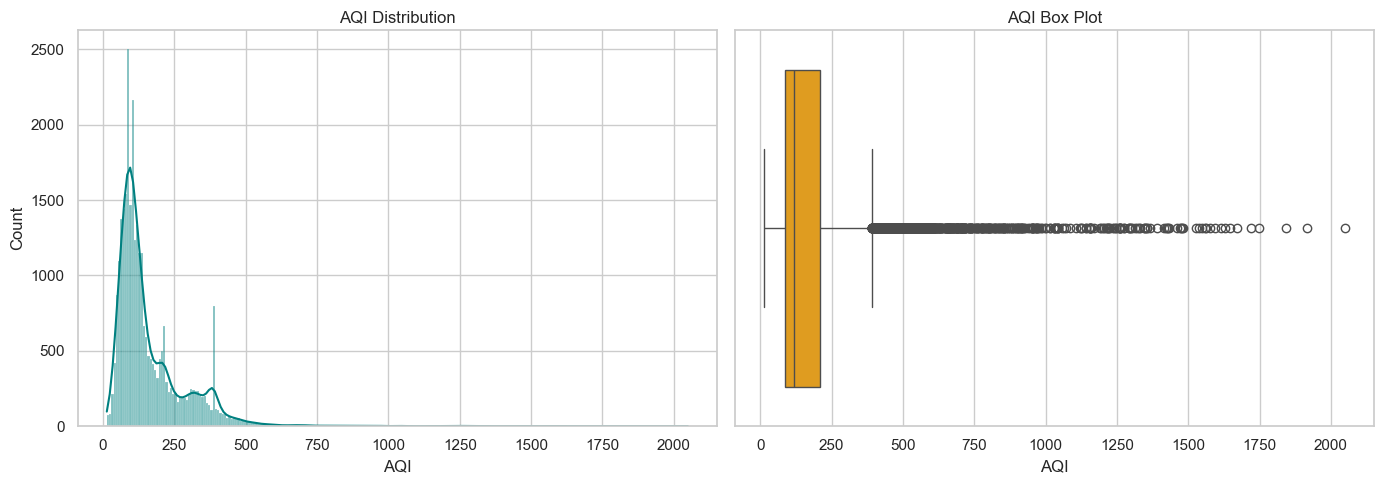

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(clean_df['AQI'], kde=True, ax=axes[0], color='teal')
axes[0].set_title('AQI Distribution')

sns.boxplot(x=clean_df['AQI'], ax=axes[1], color='orange')
axes[1].set_title('AQI Box Plot')

plt.tight_layout()
plt.show()


The distribution is clearly not perfectly balanced. Most observations fall in the moderate-to-poor range, while a smaller number of extremely high AQI values stretch the upper tail. That is exactly the kind of pattern where outlier treatment should be considered carefully rather than ignored.


## Step 8: Detect and cap outliers using IQR
Instead of deleting extreme rows, this notebook uses Winsorisation through the IQR rule. In plain language, values outside the acceptable range are capped at the lower or upper fence.

This keeps the dataset size intact while reducing the disproportionate pull of very extreme AQI values.


In [22]:
q1 = clean_df['AQI'].quantile(0.25)
q3 = clean_df['AQI'].quantile(0.75)
iqr = q3 - q1
lower_fence = q1 - 1.5 * iqr
upper_fence = q3 + 1.5 * iqr

print('Q1:', q1)
print('Q3:', q3)
print('IQR:', iqr)
print('Lower fence:', lower_fence)
print('Upper fence:', upper_fence)


Q1: 86.0
Q3: 208.0
IQR: 122.0
Lower fence: -97.0
Upper fence: 391.0


In [23]:
outliers_before = ((clean_df['AQI'] < lower_fence) | (clean_df['AQI'] > upper_fence)).sum()
clean_df['AQI_capped'] = clean_df['AQI'].clip(lower=lower_fence, upper=upper_fence)
outliers_after = ((clean_df['AQI_capped'] < lower_fence) | (clean_df['AQI_capped'] > upper_fence)).sum()

print('Outliers before capping:', outliers_before)
print('Outliers after capping :', outliers_after)


Outliers before capping: 1465
Outliers after capping : 0


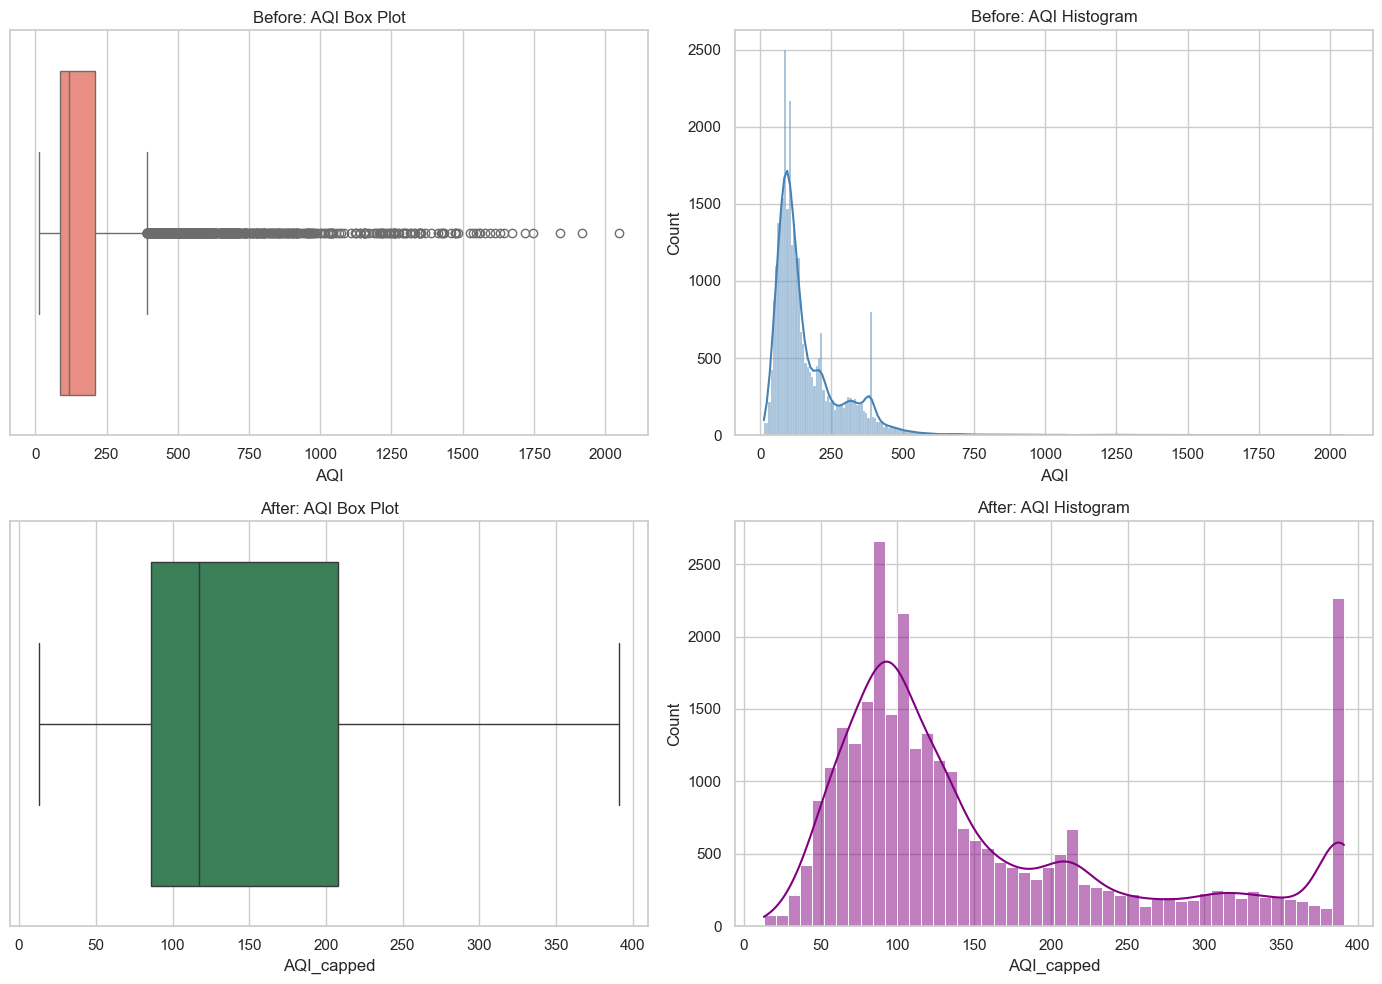

In [24]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.boxplot(x=clean_df['AQI'], ax=axes[0, 0], color='salmon')
axes[0, 0].set_title('Before: AQI Box Plot')

sns.histplot(clean_df['AQI'], kde=True, ax=axes[0, 1], color='steelblue')
axes[0, 1].set_title('Before: AQI Histogram')

sns.boxplot(x=clean_df['AQI_capped'], ax=axes[1, 0], color='seagreen')
axes[1, 0].set_title('After: AQI Box Plot')

sns.histplot(clean_df['AQI_capped'], kde=True, ax=axes[1, 1], color='purple')
axes[1, 1].set_title('After: AQI Histogram')

plt.tight_layout()
plt.show()


## Conclusion
This lab was less about flashy modeling and more about building trust in the data. By the end of the notebook, the dataset is cleaner, the missing values are handled more thoughtfully, duplicate rows are removed, AQI categories are aligned with the cleaned values, and extreme AQI values are controlled without discarding the observations entirely.

That makes the dataset far more ready for the next stage of machine learning work.
